In [ ]:
pip install util-gfsilveira

In [ ]:
#gerar gráfico
import matplotlib
#estruturação dos dados
import numpy as np
#gerar gráfico
import seaborn as sns
#gerar gráfico
import matplotlib.pyplot as plt
#Carregar o modelo
from keras.models import load_model
#salvar/carregar arquivos em diferentes formatos
import joblib

In [ ]:
#Importando o modelo contendo os valores previstos para o número de células nas imagens
modelo_maior_erro = load_model('/content/drive/MyDrive/teste/imagens_julia_quantificacao/img_e_rot_para_validação_fluores/modelo_fluore_100_75_50_25_2024-8-22.keras')
modelo_maior_erro

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


<Sequential name=sequential, built=True>

In [ ]:
X_test_maior_erro = joblib.load('/content/drive/MyDrive/teste/imagens_julia_quantificacao/img_e_rot_para_validação_fluores/imagens_validação_10%_fluore_2024-8-22.gz') #carregando arquivo
X_test_maior_erro.shape

(64, 300, 300, 3)

In [ ]:
y_test_maior_erro = joblib.load('/content/drive/MyDrive/teste/imagens_julia_quantificacao/img_e_rot_para_validação_fluores/rótulos_validação_10%_fluore_2024-8-22.gz') #carregando arquivo
y_test_maior_erro.shape

(64,)

In [ ]:
#ROTULOS SALVOS EM LISTA

lista_observado_maior_erro = list(y_test_maior_erro)
len(lista_observado_maior_erro)

64

In [ ]:
#PREDIÇÃO SALVO EM LISTA

dados_prev = modelo_maior_erro.predict(X_test_maior_erro)
lista_previsto_maior_erro = dados_prev.flatten().tolist()
len(lista_previsto_maior_erro)

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step


64

In [ ]:
import pandas as pd
from scipy.stats.stats import pearsonr as stats

<ipython-input-11-b12f1aff8071>:2: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr as stats


In [ ]:
#DATAFRAME - ORGANIZAÇÃO DAS LISTAS
#COLUNA 1 ROTULO/ COLUNA 2 PREDITO

df_maior_erro = pd.DataFrame(zip(lista_observado_maior_erro,lista_previsto_maior_erro),
                             columns = ['Observed values','Lista preditos'])
df_maior_erro.head()

,Observed values,Lista preditos
0,130,111.022247
1,126,113.622688
2,70,64.465195
3,166,160.361847
4,69,76.078781


In [ ]:
#ARREDONDANDO O PREDITO ('lista preditos')

teste = round(df_maior_erro['Lista preditos'],2)
df_maior_erro['Predicted values'] = teste
df_maior_erro.head()

,Observed values,Lista preditos,Predicted values
0,130,111.022247,111.02
1,126,113.622688,113.62
2,70,64.465195,64.47
3,166,160.361847,160.36
4,69,76.078781,76.08


In [ ]:
#REORGANIZANDO AS COLUNAS

df_maior_erro = df_maior_erro.reindex(columns=['Observed values','Predicted values','Lista preditos'])
df_maior_erro.head()

,Observed values,Predicted values,Lista preditos
0,130,111.02,111.022247
1,126,113.62,113.622688
2,70,64.47,64.465195
3,166,160.36,160.361847
4,69,76.08,76.078781


In [ ]:
#BIBLIOTECA CORRELAÇÃO
from scipy.stats.stats import spearmanr as spearman #importando a biblioteca para gráfico de correlação

<ipython-input-15-b2b9a789bed1>:2: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import spearmanr as spearman #importando a biblioteca para gráfico de correlação


In [ ]:
#CALCULO DE CORRELAÇÃO

col1_obt = 0 #Observed value
col2_prev = 1 #Predicted values
pear_pos_maior_erro = stats(df_maior_erro[df_maior_erro.columns[col1_obt]],
                            df_maior_erro[df_maior_erro.columns[col2_prev]])

TypeError: unsupported operand type(s) for +: 'float' and 'numpy.str_'

In [ ]:
from scipy import stats

# Verifique se as colunas contêm apenas valores numéricos
df_maior_erro[df_maior_erro.columns[col1_obt]] = pd.to_numeric(df_maior_erro[df_maior_erro.columns[col1_obt]], errors='coerce')
df_maior_erro[df_maior_erro.columns[col2_prev]] = pd.to_numeric(df_maior_erro[df_maior_erro.columns[col2_prev]], errors='coerce')

# Remova as linhas com valores NaN resultantes da conversão
df_maior_erro = df_maior_erro.dropna(subset=[df_maior_erro.columns[col1_obt], df_maior_erro.columns[col2_prev]])

# Calcular a correlação
pear_pos_maior_erro = stats.pearsonr(df_maior_erro[df_maior_erro.columns[col1_obt]],
                                     df_maior_erro[df_maior_erro.columns[col2_prev]])

print(pear_pos_maior_erro)

PearsonRResult(statistic=0.9334417413656544, pvalue=2.681843704596865e-29)


<Figure size 1500x1500 with 0 Axes>

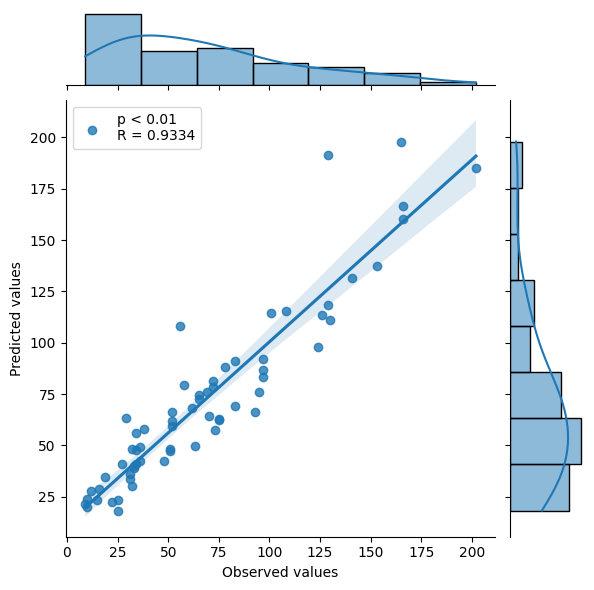

In [ ]:
plt.figure(figsize=(15,15))
sns.jointplot(
    x=df_maior_erro.columns[col1_obt],
    y=df_maior_erro.columns[col2_prev],
    kind='reg',
    data=df_maior_erro#[df_maior_erro['Lista observado'] > 300]
)

if pear_pos_maior_erro[1] < 0.01:
  plt.legend(['p < ' + '0.01' + '\nR = ' + str(round(pear_pos_maior_erro[0], 4))]) #calculando p e relse:
else:
  plt.legend(['p = ' + str(round(pear_pos_maior_erro[1],4)) + '\nR = ' + str(round(pear_pos_maior_erro[0], 4))]) #calculando p e r